# Anomaly Detection: Predictive Maintenance with AI4I 2020

**Question:** Can we learn from sensor data what a normal machine state looks like and detect rare machine failures as anomalies?

Dataset: **AI4I 2020 Predictive Maintenance Dataset** from UCI  
Source: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset


## Learning Objectives

After this notebook, you should be able to explain:

- why anomaly detection often works with many normal examples and only a few faulty examples,
- why training, validation, and test sets have different roles,
- how a `GaussianMixture` models normal data as a mixture of several Gaussian distributions,
- why accuracy can be problematic when failures are rare,
- how to interpret precision, recall, and F1 in a practical setting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the Dataset

The dataset contains 10,000 synthetically generated machine states. The features are technically interpretable, for example temperature, rotational speed, torque, and tool wear.

The target variable `Machine failure` is used only for evaluation and threshold selection. The anomaly-detection model itself will learn only from normal machine states.


In [2]:
url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"

df = pd.read_csv(url, compression="zip", encoding="utf-8-sig")
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df["Machine failure"].value_counts().rename(index={0: "normal", 1: "failure"})

Machine failure
normal     9661
failure     339
Name: count, dtype: int64

In [4]:
failure_rate = df["Machine failure"].mean()
print(f"Failure rate: {failure_rate:.2%}")
print(f"Accuracy of a dummy model that always predicts 'normal': {1 - failure_rate:.2%}")

Failure rate: 3.39%
Accuracy of a dummy model that always predicts 'normal': 96.61%


## 2. Select Features

We first use only numerical sensor features. Product ID and failure-type columns are not used as model inputs.

Important: `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` are already failure indicators. If we used them as features, the task would become too easy and would not represent the intended anomaly-detection setting.


In [5]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
target = "Machine failure"

X = df[features]
y = df[target]

X.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


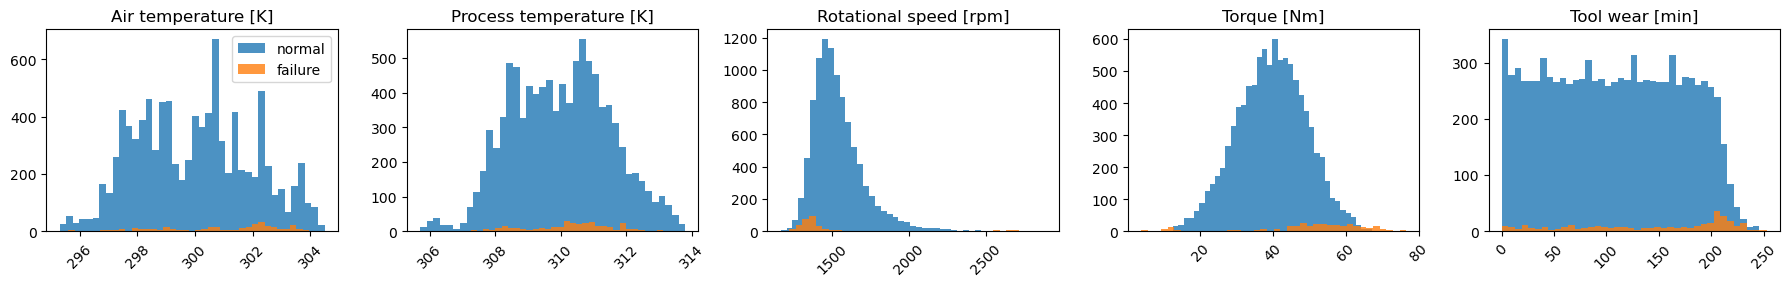

In [35]:
fig, axes = plt.subplots(1, len(features), figsize=(18, 3))

for ax, col in zip(axes, features):
    ax.hist(df.loc[y == 0, col], bins=40, alpha=0.8, label="normal")
    ax.hist(df.loc[y == 1, col], bins=40, alpha=0.8, label="failure")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

axes[0].legend()
plt.tight_layout()

## 2b. Relationship Between Torque and Rotational Speed

Before splitting the data, we inspect two physically related features: torque and rotational speed.

This scatter plot helps us see whether failure cases are simply far away from the normal data cloud or whether they overlap with normal operating states. Strong overlap is a warning sign: anomaly detection will then need a threshold trade-off and cannot separate all failures perfectly.


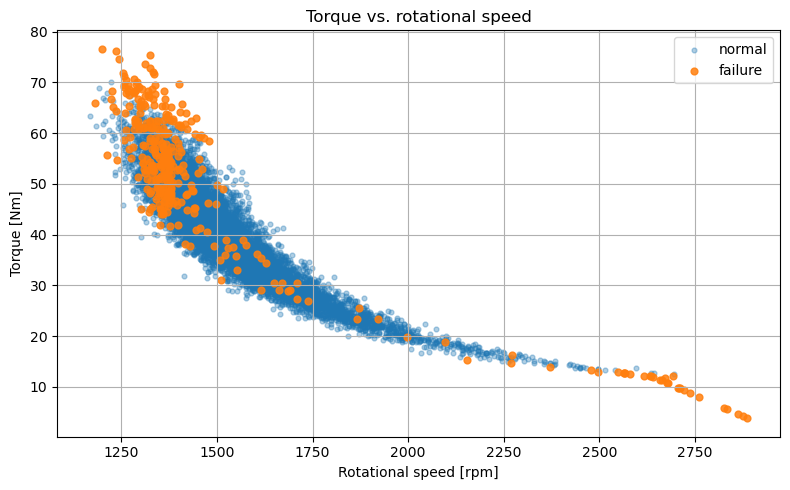

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df.loc[y == 0, "Rotational speed [rpm]"],
    df.loc[y == 0, "Torque [Nm]"],
    s=12,
    alpha=0.35,
    label="normal",
)
plt.scatter(
    df.loc[y == 1, "Rotational speed [rpm]"],
    df.loc[y == 1, "Torque [Nm]"],
    s=24,
    alpha=0.85,
    label="failure",
)
plt.xlabel("Rotational speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.title("Torque vs. rotational speed")
plt.legend()
plt.grid(True)
plt.tight_layout()


## 3. Split: Training, Validation, Test

The three datasets deliberately have different roles:

- **Training:** only normal machine states. The model learns the normal distribution from these data.
- **Validation:** normal and faulty machine states. We use this set to choose the threshold.
- **Test:** normal and faulty machine states. We use this set only at the end for an independent evaluation.

The few known failures are therefore not used to fit the anomaly-detection model. They are used only for threshold selection and evaluation.


In [52]:
normal = df[df[target] == 0].copy()
failure = df[df[target] == 1].copy()

train_normal, remaining_normal = train_test_split(
    normal,
    train_size=0.60,
    random_state=RANDOM_STATE,
)

val_normal, test_normal = train_test_split(
    remaining_normal,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

val_failure, test_failure = train_test_split(
    failure,
    test_size=0.50,
    random_state=RANDOM_STATE,
)

train_df = train_normal.copy()
val_df = pd.concat([val_normal, val_failure]).sample(frac=1, random_state=RANDOM_STATE)
test_df = pd.concat([test_normal, test_failure]).sample(frac=1, random_state=RANDOM_STATE)

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    counts = part[target].value_counts().sort_index()
    print(name)
    print(counts.rename(index={0: "normal", 1: "failure"}))
    print()

train
Machine failure
normal    5796
Name: count, dtype: int64

validation
Machine failure
normal     1932
failure     169
Name: count, dtype: int64

test
Machine failure
normal     1933
failure     170
Name: count, dtype: int64



## 4. Scaling

The features have different units: Kelvin, revolutions per minute, newton meters, and minutes. Distance-based and covariance-based methods should therefore work with scaled features.

The `StandardScaler` is fitted only on the training data. Validation and test data are then transformed with exactly these training parameters.


In [53]:
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[features])
X_val = scaler.transform(val_df[features])
X_test = scaler.transform(test_df[features])

y_val = val_df[target].to_numpy()
y_test = test_df[target].to_numpy()

## 5. Model: Gaussian Mixture Model

A `GaussianMixture` models the normal data as a mixture of several Gaussian distributions.

Connection to the lecture slides:

- The slides model normal data using probabilities or densities.
- A single Gaussian distribution is often too simple because machines can have several normal operating states.
- A Gaussian Mixture Model allows several Gaussian-like normal regions.
- Points with very low log density look atypical and are marked as anomalies.

The model is still fitted only on normal training data.


In [54]:
gmm = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=RANDOM_STATE,
)

gmm.fit(X_train)

# score_samples returns log density values.
# Larger values mean: the point fits the learned normal distribution better.
val_scores = gmm.score_samples(X_val)
test_scores = gmm.score_samples(X_test)

print(val_scores[:10])


[ -5.86244794  -4.18792725  -4.33780882  -4.26690577 -24.72929591
  -5.61086982  -3.94705233  -5.05502732  -6.57062685  -4.05215785]


### Interpreting the Score Distribution

The histogram shows how well the Gaussian Mixture Model separates normal and faulty machine states using the learned normality density.

- The x-axis shows the GMM log-density score: farther to the right means "fits the normal training data better".
- The blue bars are normal machine states from the validation set.
- The orange bars are known failure states from the validation set.
- Ideally, failures would be clearly shifted to the left of the normal data.
- If both histograms overlap, no threshold can separate them perfectly: there will be either false alarms or missed failures.

The next step is therefore to choose a threshold on the validation set that gives the desired compromise between precision and recall.


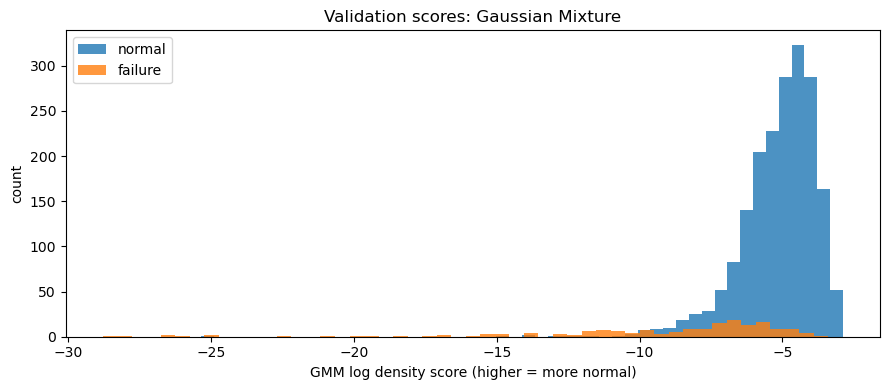

In [55]:
plt.figure(figsize=(9, 4))
plt.hist(val_scores[y_val == 0], bins=50, alpha=0.8, label="normal")
plt.hist(val_scores[y_val == 1], bins=50, alpha=0.8, label="failure")
plt.xlabel("GMM log density score (higher = more normal)")
plt.ylabel("count")
plt.title("Validation scores: Gaussian Mixture")
plt.legend()
plt.tight_layout()


## 6. Select a Threshold with the Validation Set

The model returns a log-density score for each point. Now we need a decision rule:

`score < threshold` means **anomaly / possible machine failure**.

We choose the threshold on the validation set. Here we optimize the F1 score for the positive class `failure = 1`.


In [39]:
def predict_from_scores(scores, threshold):
    return (scores < threshold).astype(int)


threshold_candidates = np.quantile(val_scores, np.linspace(0.001, 0.30, 400))

rows = []
for threshold in threshold_candidates:
    y_pred = predict_from_scores(val_scores, threshold)
    rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_val, y_pred),
        "alarms": y_pred.sum(),
    })

threshold_results = pd.DataFrame(rows)
threshold_results.sort_values("f1", ascending=False).head(10)


,threshold,precision,recall,f1,accuracy,alarms
88,-8.054505,0.546099,0.455621,0.496774,0.925750,141
68,-8.528454,0.627273,0.408284,0.494624,0.932889,110
92,-7.948433,0.530612,0.461538,0.493671,0.923846,147
89,-8.013389,0.538462,0.455621,0.493590,0.924798,143
69,-8.487135,0.621622,0.408284,0.492857,0.932413,111
90,-7.989226,0.534722,0.455621,0.492013,0.924322,144
87,-8.087886,0.542857,0.449704,0.491909,0.925274,140
67,-8.602180,0.629630,0.402367,0.490975,0.932889,108
93,-7.922085,0.523490,0.461538,0.490566,0.922894,149
70,-8.449629,0.610619,0.408284,0.489362,0.931461,113


In [40]:
best = threshold_results.sort_values("f1", ascending=False).iloc[0]
best_threshold = best["threshold"]

print(best)
print(f"\nChosen threshold: {best_threshold:.3f}")

threshold     -8.054505
precision      0.546099
recall         0.455621
f1             0.496774
accuracy       0.925750
alarms       141.000000
Name: 88, dtype: float64

Chosen threshold: -8.055


### Interpreting the Precision-Recall Curve

The curve shows the trade-off between **precision** and **recall** on the validation set.

Important: **Each point on the curve corresponds to a different threshold** for the GMM score.

- A strict threshold raises an alarm only for very unusual points. This often increases precision, but it may miss failures and reduce recall.
- A more permissive threshold raises alarms earlier. This often increases recall, but it creates more false alarms and reduces precision.
- A point farther to the right means: more real failures are detected.
- A point higher up means: alarms are correct more often.

For predictive maintenance, we must decide which error is more expensive in the application: an unnecessary maintenance alarm or a missed machine failure.


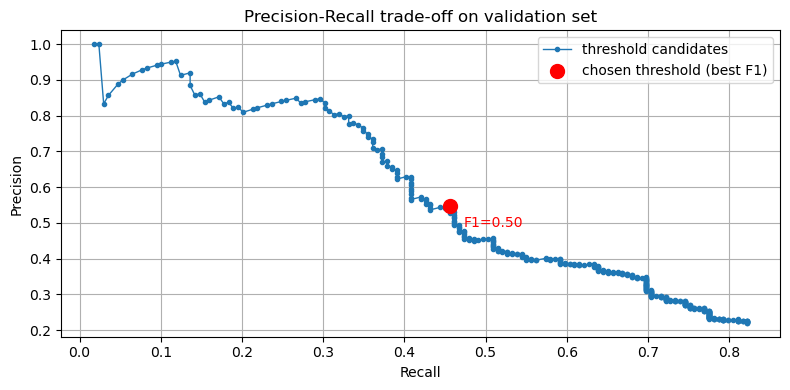

In [59]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_results["recall"], threshold_results["precision"], marker=".", linewidth=1, label="threshold candidates")

plt.scatter(
    best["recall"],
    best["precision"],
    color="red",
    s=100,
    zorder=3,
    label="chosen threshold (best F1)",
)
plt.annotate(
    f"F1={best['f1']:.2f}",
    xy=(best["recall"], best["precision"]),
    xytext=(10, -15),
    textcoords="offset points",
    color="red",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall trade-off on validation set")
plt.grid(True)
plt.legend()
plt.tight_layout()


## 7. Final Evaluation on the Test Set

Now nothing is optimized anymore. The test set is used only for the independent evaluation of the selected Gaussian Mixture model and threshold.


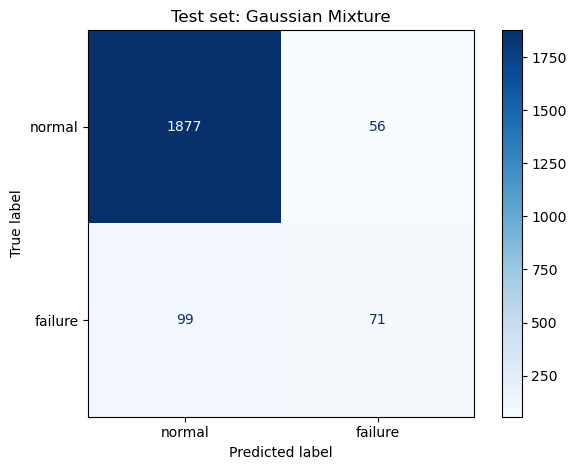

In [61]:
y_test_pred = predict_from_scores(test_scores, best_threshold)

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["normal", "failure"])
disp.plot(cmap="Blues")
plt.title("Test set: Gaussian Mixture")
plt.tight_layout()


## 8. Interpreting Precision and Recall

For `failure = 1`:

- **Precision:** When the system raises an alarm, how often is the machine actually faulty?
- **Recall:** How many of the actually faulty machine states do we detect?
- **F1:** A compromise between precision and recall.

In predictive maintenance, recall is often especially important because a missed failure can be expensive or dangerous. Too many false alarms are also problematic because maintenance costs resources.


In [15]:
tn, fp, fn, tp = cm.ravel()

print(f"True positives  (failure correctly detected): {tp}")
print(f"False positives (normal machine flagged):     {fp}")
print(f"False negatives (failure missed):            {fn}")
print(f"True negatives  (normal correctly ignored):  {tn}")

True positives  (failure correctly detected): 74
False positives (normal machine flagged):     141
False negatives (failure missed):            96
True negatives  (normal correctly ignored):  1792


## 9. Summary

This notebook shows the complete anomaly-detection pipeline with Gaussian Mixture Models:

1. Understand the data and identify rare failures.
2. Train the model only on normal machine states.
3. Model normality as a mixture of several Gaussian distributions.
4. Use the validation set to choose a suitable threshold.
5. Use the test set only once for the final evaluation.
6. Focus on precision, recall, and F1 instead of accuracy alone.

The central message:

Anomaly detection is not just a classification problem with rare labels. We first model normality and then decide which observations are unusual enough to be treated as anomalies.
